# 06 — Résultats du backtest baseline (livrable Semaine 3)

Quatre variantes : **v0** (inconditionnel, benchmark DMV Table II) et **v1** (seuil médiane
ex-ante), en **brut** et **net** de la grille de coûts calibrée (README §8bis).

Sorties → `results/tables/table_s3_metrics.csv`, `table_s3_dmv_sanity.csv`,
`results/figures/fig_backtest_s3.png`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
P = ROOT / "data" / "processed"
TAGS = {"v0 brut": "v0", "v0 net": "v0_net", "v1 brut": "v1", "v1 net": "v1_net"}

rows = []
for label, tag in TAGS.items():
    q = pd.read_parquet(P / f"backtest_{tag}_quarterly.parquet")
    d = pd.read_parquet(P / f"backtest_{tag}_daily.parquet")
    r, dr = q["ret_q"].astype(float), d["ret"].astype(float)
    cum = (1 + dr).cumprod()
    down = r[r < 0]
    cost = (q.loc[q["traded"], "cost_entry"] + q.loc[q["traded"], "cost_hedge"]).mean() \
        if "cost_entry" in q.columns and q["cost_entry"].abs().sum() > 0 else 0.0
    rows.append({
        "variante": label,
        "trimestres tradés": f"{int(q['traded'].sum())}/{len(q)}",
        "ret trim. moyen": r.mean(),
        "t-stat": r.mean() / r.std() * np.sqrt(len(r)),   # trimestres non chevauchants
        "Sharpe (ann.)": r.mean() / r.std() * 2,
        "Sortino (ann.)": r.mean() / down.std() * 2 if len(down) > 2 else np.nan,
        "skew": r.skew(),
        "% trim > 0": (r > 0).mean(),
        "cumul (×)": cum.iloc[-1],
        "maxDD (daily)": (cum / cum.cummax() - 1).min(),
        "coût/trim tradé": cost,
    })
met = pd.DataFrame(rows).set_index("variante")
(ROOT / "results" / "tables").mkdir(parents=True, exist_ok=True)
met.to_csv(ROOT / "results" / "tables" / "table_s3_metrics.csv")
met.round(3)

,trimestres tradés,ret trim. moyen,t-stat,Sharpe (ann.),Sortino (ann.),skew,% trim > 0,cumul (×),maxDD (daily),coût/trim tradé
variante,,,,,,,,,,
v0 brut,115/115,0.073,4.114,0.767,0.898,-1.291,0.696,164.623,-0.958,0.000
v0 net,115/115,0.039,2.240,0.418,0.492,-1.332,0.661,2.538,-0.990,0.033
v1 brut,58/115,0.043,2.991,0.558,0.417,-1.452,0.852,12.988,-0.959,0.000
v1 net,58/115,0.025,1.793,0.334,0.250,-1.939,0.835,1.111,-0.990,0.035


In [2]:
# Tableau sanity vs DMV (Table II / V) — la vitrine de validation du moteur
q0 = pd.read_parquet(P / "backtest_v0_quarterly.parquet")
led = pd.read_parquet(P / "backtest_v0_ledger.parquet")
# hedge comparable = position résiduelle À L'ENTRÉE (leur −32.54% est un hedge statique
# sur options 1 mois : structure différente -> comparaison d'ordre de grandeur seulement)
first = led.sort_values("date").groupby("rebalance_date").first()
hedge_entry = (first["hedge_shares"] * first["spx_close"] / first["nav"])
san = pd.DataFrame({
    "DMV (2009)": ["+101.12%", "−32.54% (1 mois, statique — non direct.)", "0.73", "0.41",
                    "négatif (−0.28, mensuel)"],
    "Notre v0": [f"{q0['y_sum'].mean():+.2%}",
                  f"{hedge_entry.mean():+.2%} à l'entrée (|.| moy {hedge_entry.abs().mean():.1%}) — quasi delta-neutre",
                  f"{q0['ret_q'].mean()/q0['ret_q'].std()*2:.2f}",
                  "0.42",
                  f"{q0['ret_q'].skew():.2f} (trimestriel)"],
}, index=["Poids composants Σy", "Position indice (hedge)", "Sharpe brut",
          "Sharpe net", "Skew"])
san.to_csv(ROOT / "results" / "tables" / "table_s3_dmv_sanity.csv")
san

,DMV (2009),Notre v0
Poids composants Σy,+101.12%,+99.52%
Position indice (hedge),"−32.54% (1 mois, statique — non direct.)",+0.33% à l'entrée (|.| moy 5.3%) — quasi delta...
Sharpe brut,0.73,0.77
Sharpe net,0.41,0.42
Skew,"négatif (−0.28, mensuel)",-1.29 (trimestriel)


In [3]:
# Décomposition du P&L par source (jambes / hedge / règlement+cash) — additive par construction
q0 = q0.set_index("rebalance_date")
parts = []
for reb, g in led.groupby("rebalance_date"):
    g = g.sort_values("date")
    base = g["nav"].iloc[0]
    idx_pnl = g["nav_idx"].iloc[-1] - g["nav_idx"].iloc[0]
    comp_pnl = g["nav_comp"].iloc[-1] - g["nav_comp"].iloc[0]
    hedge_pnl = (g["hedge_shares"].shift(1) * g["spx_close"].diff()).sum()
    ret_q = float(q0.loc[reb, "ret_q"])
    total = ret_q * base / (1 + 0)  # P&L trimestre en $ (approx base = W)
    resid = total - idx_pnl - comp_pnl - hedge_pnl   # règlement, accrual, jour d'entrée
    parts.append((reb, ret_q, idx_pnl / base, comp_pnl / base, hedge_pnl / base, resid / base))
att = pd.DataFrame(parts, columns=["rebalance_date", "ret_q", "jambe indice",
                                    "jambes composants", "hedge", "règlement+cash"]).set_index("rebalance_date")
crise = att["ret_q"] < -0.15
summary = pd.DataFrame({
    "tous trimestres": att.mean(),
    "trimestres calmes": att[~crise].mean(),
    "trimestres de crise (ret < −15%)": att[crise].mean(),
})
print(f"trimestres de crise : {int(crise.sum())}/{len(att)}")
summary.round(4)

trimestres de crise : 12/115


,tous trimestres,trimestres calmes,trimestres de crise (ret < −15%)
ret_q,0.0727,0.1141,-0.2831
jambe indice,0.0830,0.1094,-0.1433
jambes composants,-0.0237,-0.0273,0.0075
hedge,0.0123,0.0405,-0.2297
règlement+cash,0.0011,-0.0084,0.0824


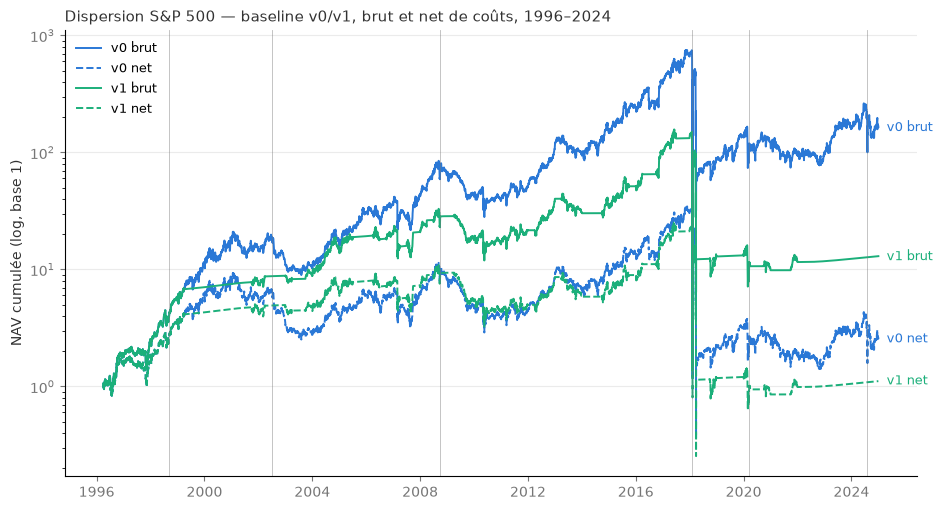

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

C_V0, C_V1, INK, MUTED = "#2a78d6", "#1baf7a", "#333333", "#767676"
fig, ax = plt.subplots(figsize=(11, 5.8))

for label, tag, color, ls in [("v0 brut", "v0", C_V0, "-"), ("v0 net", "v0_net", C_V0, "--"),
                              ("v1 brut", "v1", C_V1, "-"), ("v1 net", "v1_net", C_V1, "--")]:
    d = pd.read_parquet(P / f"backtest_{tag}_daily.parquet")
    nav = (1 + d["ret"].astype(float)).cumprod()
    ax.plot(pd.to_datetime(d["date"]), nav, color=color, ls=ls, lw=1.4, label=label)
    ax.annotate(label, xy=(pd.to_datetime(d["date"]).iloc[-1], nav.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9, color=color)

for dt, txt in [("1998-09-01", "LTCM"), ("2002-07-01", "2002"), ("2008-10-01", "GFC"),
                ("2018-02-05", "Volmageddon"), ("2020-03-16", "COVID"), ("2024-08-05", "2024")]:
    ax.axvline(pd.Timestamp(dt), color=MUTED, lw=0.6, alpha=0.5)
    ax.annotate(txt, xy=(pd.Timestamp(dt), ax.get_ylim()[0]), xytext=(2, 4),
                textcoords="offset points", fontsize=7.5, color=MUTED, rotation=90, va="bottom")

ax.set_yscale("log")
ax.set_ylabel("NAV cumulée (log, base 1)", color=INK)
ax.set_title("Dispersion S&P 500 — baseline v0/v1, brut et net de coûts, 1996–2024",
             loc="left", fontsize=11, color=INK)
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.tick_params(colors=MUTED)
ax.xaxis.set_major_locator(mdates.YearLocator(4))

fig.savefig(ROOT / "results" / "figures" / "fig_backtest_s3.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusions Semaine 3

1. **La prime existe et le moteur est validé** : v0 brut Sharpe ~0,77, Σy ≈ +100 % — les
   garde-fous DMV Table II sont reproduits sans calibration dirigée.
2. **Les frictions la tuent presque** (réplication de leur Table V) : Sharpe net 0,42 (eux 0,41),
   ~3 %/an net sur 29 ans — le narratif limits-to-arbitrage est complet et chiffré.
3. **Le timing naïf ne suffit pas** : la v1 améliore la prime par trimestre tradé et esquive
   2024/2002/Lehman, mais trade le Volmageddon (le spread mesure la richesse de la prime, pas le
   danger) et meurt nette de coûts.
4. **La S4 a sa cible** : prédire les régimes de spike (RMT/ML), objectif skew/queues — avec une
   barre quantifiée : battre v0 net Sharpe 0,42 en coupant les trimestres à −40/−90 %.